In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import joblib

In [ ]:
df = pd.read_csv(
    "train_FD001.txt",
    sep=r"\s+",
    header=None
)

df = df.dropna(axis=1)

In [ ]:
#Rename Columns
columns = [
    "Engine_ID",
    "Cycle",
    "Op1",
    "Op2",
    "Op3"
]
for i in range(1,22):
    columns.append(f"Sensor_{i}")

df.columns = columns


In [ ]:
#Calculate Remaining Useful Life
max_cycle = df.groupby("Engine_ID")["Cycle"].max()

df = df.merge(
    max_cycle.rename("MaxCycle"),
    on="Engine_ID"
)

df["RUL"] = df["MaxCycle"] - df["Cycle"]

df.drop("MaxCycle", axis=1, inplace=True)

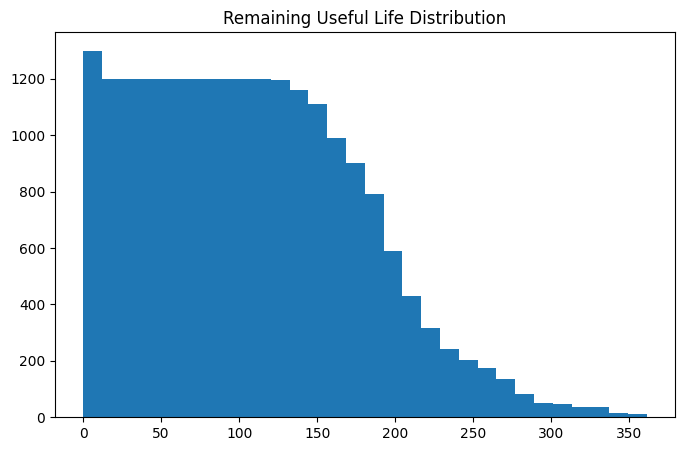

In [ ]:
#Visualize Data
plt.figure(figsize=(8,5))

plt.hist(df["RUL"], bins=30)

plt.title("Remaining Useful Life Distribution")

plt.show()

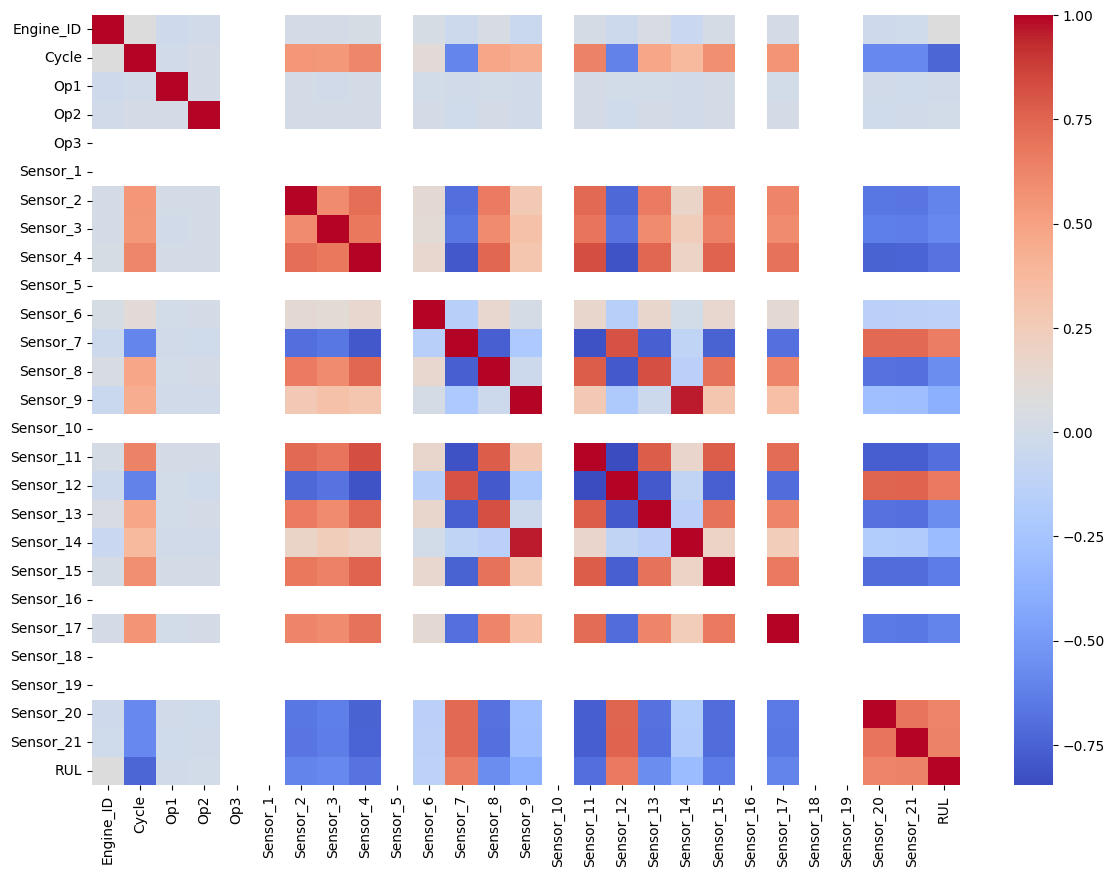

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.show()

In [ ]:
#Prepare Features
X = df.drop(
    ["Engine_ID","Cycle","RUL"],
    axis=1
)

y = df["RUL"]

In [ ]:
#Train-Test Split
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

In [ ]:
#Train XGBoost
model = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    random_state=42

)

model.fit(

    X_train,

    y_train

)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
import xgboost
import joblib

print("XGBoost version:", xgboost.__version__)

# Save the trained model again
joblib.dump(model, "predictive_model.pkl")

print("Model saved successfully!")

XGBoost version: 3.3.0
Model saved successfully!


In [ ]:
from google.colab import files

files.download("predictive_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Create a sample input file using the first 5 rows

sample_input = X.head(5)

sample_input.to_csv("sample_input.csv", index=False)

print("sample_input.csv created successfully!")

sample_input.csv created successfully!


In [ ]:
from google.colab import files

files.download("sample_input.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Evaluate Model
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test,predictions)

rmse = np.sqrt(mean_squared_error(y_test,predictions))

r2 = r2_score(y_test,predictions)

print("MAE :",mae)

print("RMSE :",rmse)

print("R2 :",r2)

MAE : 29.795137405395508
RMSE : 41.68694363384356
R2 : 0.6196368336677551


In [ ]:
#Test Prediction
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print("Predicted RUL :",prediction[0])

print("Actual RUL :",y_test.iloc[0])

Predicted RUL : 120.14105
Actual RUL : 135


In [ ]:
import xgboost
print(xgboost.__version__)

3.3.0


In [ ]:
pip install xgboost==2.1.4


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 6.0 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.3.0
    Uninstalling xgboost-3.3.0:
      Successfully uninstalled xgboost-3.3.0


In [ ]:
test_input = test_df.drop(columns=["Engine_ID", "Cycle"])
test_input.to_csv("test_input.csv", index=False)